## Modelo SIR

Toma como principio dividir en clases a la población a estudiar:

- **Susceptibles = S`(t)** 
  - Individuos que no son inmunes, por lo que es posible que se infecten.

- **Infectados = I(t)**
  - Infectados en el momento de interés y que pueden transmitir la enfermedad a los susceptibles.

- **Removidos = R(t)**
  - Individuos inmunes a la infección, por lo que no afectan la dinámica de la infección.
  - No transmiten la enfermedad.

Si Consideramos la poblacion total $= N$, por lo que:

$C = S(t) + I(t) + R(t)$

Asi nuestro modelo es:

$$
\dot S = -\beta S I
$$

$$
\dot I = \beta S I - \gamma I
$$

$$
\dot R = \gamma I
$$


### (2)

Si ahora solo consideramos  
$$
C = S(t) + I(t),
$$
pues estamos suponiendo que no hay población inmune y el flujo solo es estar infectado o ser susceptible, y cuyo modelo es:

$$
\frac{dS}{dt} = -\beta S I + \gamma I
$$

$$
\frac{dI}{dt} = \beta S I - \gamma I
$$

donde:

- $\beta$ es la tasa de infección.
- $\gamma$ es la tasa de recuperación.

Como
$$
C = S + I,
$$
entonces
$$
S = C - I.
$$

Así, podemos reducir el sistema a una única ecuación.

Como
$$
\frac{dI}{dt} = \beta S I - \gamma I,
$$
sustituyendo \(S = C - I\) se obtiene:

$$
\frac{dI}{dt} = \beta I (C - I) - \gamma I
$$

o equivalentemente,

$$
\frac{dI}{dt}
= (\beta C - \gamma)\, I
\left[
1 - \frac{I}{\frac{\beta C - \gamma}{\beta}}
\right].
$$

 Número reproductivo básico

Definimos el **número reproductivo básico** como

$$
R_0 = \frac{\beta C}{\gamma}.
$$

- Si
  $$
  \frac{\beta C}{\gamma} < 1,
  $$
  entonces los susceptibles tienden a \(C\) y
  $$
  (0,0,0)
  $$
  es un **punto estable**.

- Si
  $$
  \frac{\beta C}{\gamma} > 1,
  $$
  el número de infectados se mantiene positivo y tiende a
  $$
  C - \frac{\gamma}{\beta},
  $$
  y
  $$
  (0,0,0)
  $$
  es un **punto inestable**.


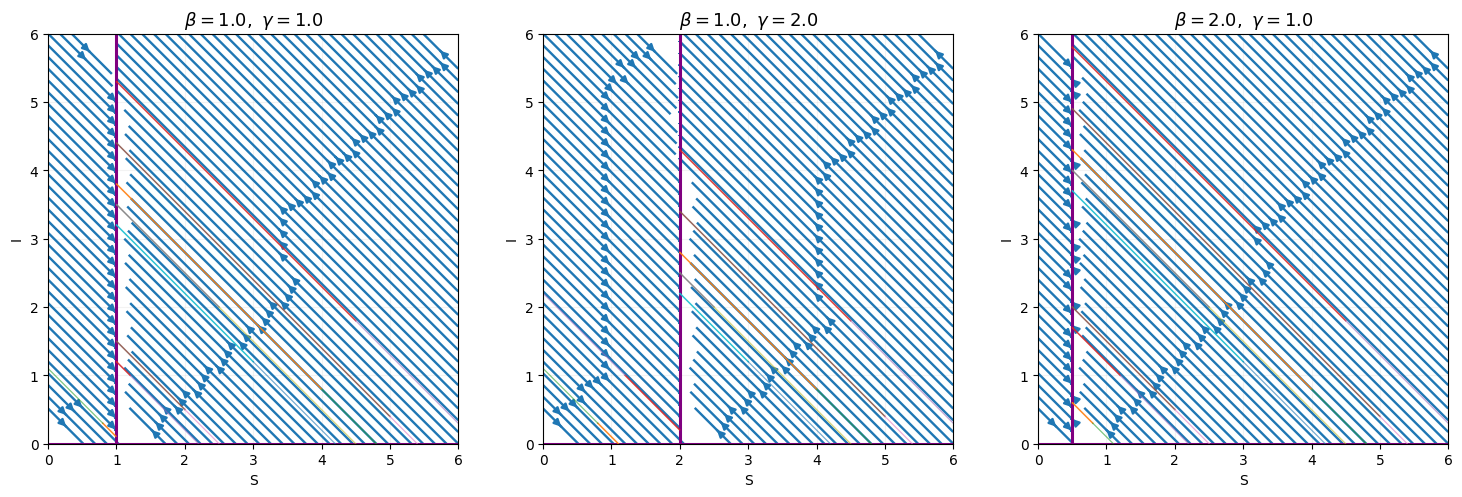

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def system(t, z, beta, gamma):
    S, I = z
    dS = -beta*S*I + gamma*I
    dI = beta*S*I - gamma*I
    return [dS, dI]

def plot_phase(beta, gamma, ax, xlim=(0, 6), ylim=(0, 6)):
    # Malla
    S = np.linspace(xlim[0], xlim[1], 300)
    I = np.linspace(ylim[0], ylim[1], 300)
    SS, II = np.meshgrid(S, I)

    dS = -beta*SS*II + gamma*II
    dI = beta*SS*II - gamma*II

    # Campo
    ax.streamplot(
        SS, II, dS, dI,
        density=1.2,
        linewidth=1.7,
        arrowsize=1.0
    )

    # Nulclinas
    yy = np.linspace(ylim[0], ylim[1], 500)

    # I = 0
    ax.plot(S, np.zeros_like(S), color='purple', linewidth=2.2)

    # S = gamma/beta
    if beta != 0:
        Sc = gamma / beta
        ax.plot(np.full_like(yy, Sc), yy, color='purple', linewidth=2.2)

    # Algunas trayectorias
    initials = [
        (0.8, 0.3), (1.2, 1.0), (2.0, 0.5), (2.5, 2.0),
        (3.0, 1.2), (4.0, 0.8), (4.5, 1.8), (5.0, 0.4)
    ]

    t_eval = np.linspace(0, 20, 1200)
    t_eval_back = np.linspace(0, -10, 600)

    for z0 in initials:
        sol = solve_ivp(
            system, (0, 20), z0, args=(beta, gamma,),
            t_eval=t_eval, rtol=1e-7, atol=1e-9
        )
        ax.plot(sol.y[0], sol.y[1], lw=1.1, alpha=0.9)

        sol_back = solve_ivp(
            system, (0, -10), z0, args=(beta, gamma,),
            t_eval=t_eval_back, rtol=1e-7, atol=1e-9
        )
        ax.plot(sol_back.y[0], sol_back.y[1], lw=0.9, alpha=0.6)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_title(fr'$\beta={beta},\ \gamma={gamma}$', fontsize=13)
    ax.set_xlabel('S')
    ax.set_ylabel('I')
    ax.grid(alpha=0.15)

def make_figure():
    params = [(1.0, 1.0), (1.0, 2.0), (2.0, 1.0)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    for ax, (beta, gamma) in zip(axes, params):
        plot_phase(beta, gamma, ax)

    plt.tight_layout()
    plt.show()

make_figure()